
# Revisiting my 2021 Master's Thesis in Python
## Parte 2 — Historical model reproduction

Questa seconda parte ricostruisce in Python la fase predittiva della tesi del 2021:

- Logistic Regression
- Linear Discriminant Analysis (LDA)
- Support Vector Machine (RBF)
- dataset completo vs dataset numerico
- SMOTE
- ROSE
- MWMOTE

L'obiettivo **non** è ancora applicare la metodologia che userei oggi. In questa parte provo invece a capire quanto sia riproducibile il lavoro originale e quali differenze emergano passando dagli script R conservati a un'esecuzione Python verificabile.

### Regole della replica

1. Gli errori puramente esecutivi degli script R vengono corretti (`test_smote`, riferimenti a colonne per posizione, ecc.).
2. Lo scaling del dataset numerico viene volutamente effettuato **prima dello split**, come nello script storico. Nella Parte 3 questo verrà corretto.
3. Lo split è casuale 80/20 con seed `1`, ma R e NumPy utilizzano procedure RNG differenti: non ci si aspetta lo stesso identico insieme di osservazioni.
4. **SMOTE** viene riprodotto secondo la logica `perc.over=100, perc.under=200` dello script R.
5. Per **ROSE** e **MWMOTE** non è disponibile in questo ambiente una implementazione Python standard equivalente ai package R utilizzati nel 2021. Vengono quindi costruiti due equivalenti trasparenti, indicati esplicitamente come `ROSE-like` e `MWMOTE-like`. I risultati non vanno interpretati come replica 1:1 dei valori della tesi.


In [1]:

from pathlib import Path
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = Path("Data_Frame_Gstore_sample.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/Data_Frame_Gstore_sample.csv")



## 1. Cleaning condiviso con la Parte 1

Manteniamo le correzioni puramente tecniche già individuate nella revisione:

- `country` viene controllato sulla propria colonna;
- `Windows Phone` viene realmente ricodificato;
- l'ora è estratta direttamente dal timestamp in formato 0–23;
- ricavo monetario e target binaria sono mantenuti separati.


In [2]:

def clean_gstore(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    object_cols = df.select_dtypes(include=["object", "string"]).columns
    for col in object_cols:
        s = df[col].astype("string")
        df[col] = s.mask(s.eq("not available in demo dataset"))

    df = df.dropna(axis=1, how="all")
    df["transactionRevenue"] = pd.to_numeric(
        df["transactionRevenue"], errors="coerce"
    ).fillna(0)

    drop_cols = [
        "adwordsClickInfo.gclId", "adwordsClickInfo.slot",
        "adwordsClickInfo.page", "adwordsClickInfo.adNetworkType",
        "adwordsClickInfo.isVideoAd", "adContent", "keyword",
        "referralPath", "networkDomain", "campaign",
        "socialEngagementType", "city", "metro", "region"
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    for col, value in [("newVisits", 0), ("bounces", 0), ("pageviews", 1)]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(value)

    if "isTrueDirect" in df.columns:
        df["isTrueDirect"] = df["isTrueDirect"].astype("object").where(
            df["isTrueDirect"].notna(), False
        )

    source = df["source"].astype("string")
    df["source"] = np.select(
        [
            source.str.contains("google", case=False, na=False),
            source.str.contains("youtube", case=False, na=False),
            source.str.contains("direct", case=False, na=False)
        ],
        ["Google", "Youtube", "Direct"],
        default="Altri"
    )

    for col in ["continent", "subContinent", "country"]:
        mask = df[col].astype("string").str.contains(
            "not set", case=False, na=False
        )
        df.loc[mask, col] = "Sconosciuto"

    os_keep = ["Android", "Chrome OS", "iOS", "Linux", "Macintosh", "Windows"]
    df["operatingSystem"] = df["operatingSystem"].where(
        df["operatingSystem"].isin(os_keep), "Altri OS"
    )

    browser_keep = ["Chrome", "Edge", "Firefox", "Internet Explorer", "Safari"]
    df["browser"] = df["browser"].where(
        df["browser"].isin(browser_keep), "Altri"
    )

    df["date"] = pd.to_datetime(
        df["date"].astype(str), format="%Y%m%d", errors="coerce"
    )
    df["visitStartTime"] = pd.to_datetime(
        pd.to_numeric(df["visitStartTime"], errors="coerce"),
        unit="s", utc=True
    )

    for col in [
        "visitNumber", "visits", "hits", "pageviews",
        "newVisits", "bounces", "transactionRevenue"
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["channelGrouping"] = df["channelGrouping"].replace("(Other)", "Altri")

    rare_subcontinents = [
        "Caribbean", "Central Asia", "Eastern Africa", "Melanesia",
        "Micronesian Region", "Middle Africa", "Northern Africa",
        "Polynesia", "Southern Africa", "Western Africa",
        "Unknown", "Sconosciuto"
    ]
    df.loc[df["subContinent"].isin(rare_subcontinents), "subContinent"] = "Altri"

    df["dow"] = ((df["visitStartTime"].dt.dayofweek + 1) % 7) + 1
    df["month"] = df["date"].dt.month
    df["hours"] = df["visitStartTime"].dt.hour

    df["purchase"] = (df["transactionRevenue"] > 0).astype(int)
    df["newVisits"] = df["newVisits"].fillna(0).astype(int)

    final_drop = [
        "Unnamed: 0", "X1", "fullVisitorId", "sessionId", "visitId",
        "isMobile", "visits", "isTrueDirect", "deviceCategory",
        "bounces", "medium"
    ]
    df = df.drop(columns=[c for c in final_drop if c in df.columns])

    return df


raw = pd.read_csv(DATA_PATH, encoding="cp1252", low_memory=False)
df = clean_gstore(raw)

print(df.shape)
print(df["purchase"].value_counts())


(25000, 18)
purchase
0    24677
1      323
Name: count, dtype: int64



## 2. Una piccola incongruenza già emersa rileggendo la tesi

Nel testo della tesi la distribuzione è indicata correttamente come circa:

- **98,7% non acquisto**
- **1,3% acquisto**

Nella tabella del paragrafo 4.4.1, però, i valori `19.739 / 261` del training set e `4.938 / 62` del test set sono mostrati sotto intestazioni **Acquisto / Non acquisto** che risultano invertite rispetto alla distribuzione reale.

È un dettaglio grafico, non un errore dell'analisi, ma è esattamente il tipo di cosa che emerge rileggendo un lavoro dopo alcuni anni.



## 3. Dataset per la modellazione

Il ramo **Numerico** della tesi utilizzava sette predittori:

`visitNumber, hits, pageviews, newVisits, dow, month, hours`

Il ramo **Originale** utilizzava anche le variabili qualitative. In Python le categorie vengono trasformate con one-hot encoding, che è la traduzione più naturale del trattamento dei factor in un model matrix.

Le variabili `date` e `visitStartTime`, presenti negli script storici, vengono trasformate in valori numerici per rendere il modello eseguibile.


In [3]:

model_df = df[
    [
        "channelGrouping", "date", "visitNumber", "visitStartTime",
        "browser", "operatingSystem", "continent", "subContinent",
        "country", "hits", "pageviews", "newVisits", "source",
        "dow", "month", "hours", "purchase"
    ]
].copy()

model_df["date_numeric"] = (
    model_df["date"] - pd.Timestamp("1970-01-01")
).dt.days.astype(float)

model_df["visitStartTime_numeric"] = (
    model_df["visitStartTime"].astype("int64") / 1e9
)

model_df = model_df.drop(columns=["date", "visitStartTime"])

categorical_features = [
    "channelGrouping", "browser", "operatingSystem",
    "continent", "subContinent", "country", "source"
]
numeric_all_features = [
    "date_numeric", "visitNumber", "visitStartTime_numeric",
    "hits", "pageviews", "newVisits", "dow", "month", "hours"
]
numeric_features = [
    "visitNumber", "hits", "pageviews",
    "newVisits", "dow", "month", "hours"
]

X_num = model_df[numeric_features].astype(float)
y = model_df["purchase"].astype(int)

display(model_df.head())


,channelGrouping,visitNumber,browser,operatingSystem,continent,subContinent,country,hits,pageviews,newVisits,source,dow,month,hours,purchase,date_numeric,visitStartTime_numeric
0,Social,1,Chrome,Windows,Americas,Central America,Mexico,1,1.0000,1,Youtube,3,2,19,0,"17,225.0000","1,488,310,191.0000"
1,Social,1,Chrome,Windows,Europe,Northern Europe,Norway,1,1.0000,1,Youtube,6,10,11,0,"17,095.0000","1,477,049,492.0000"
2,Organic Search,1,Safari,Macintosh,Americas,South America,Brazil,9,9.0000,1,Google,2,2,18,0,"17,210.0000","1,487,011,296.0000"
3,Direct,8,Chrome,Chrome OS,Europe,Western Europe,France,1,1.0000,0,Direct,4,3,16,0,"17,247.0000","1,490,201,370.0000"
4,Organic Search,1,Chrome,Windows,Asia,Southeast Asia,Philippines,2,2.0000,1,Google,2,1,8,0,"17,168.0000","1,483,344,410.0000"



## 4. Split storico 80/20

Lo script R utilizzava `set.seed(1)` e un campionamento casuale di 20.000 righe.

Qui utilizziamo anch'esso seed `1`, ma **non forziamo artificialmente** gli stessi conteggi: il generatore casuale e l'algoritmo di sampling di R non coincidono con NumPy.


In [4]:

rng = np.random.RandomState(1)

train_idx = np.sort(
    rng.choice(len(model_df), size=round(len(model_df) * 0.8), replace=False)
)
test_mask = np.ones(len(model_df), dtype=bool)
test_mask[train_idx] = False
test_idx = np.where(test_mask)[0]

y_train = y.iloc[train_idx].to_numpy()
y_test = y.iloc[test_idx].to_numpy()

split_counts = pd.DataFrame(
    {
        "Python replica": [
            (y_train == 0).sum(),
            (y_train == 1).sum(),
            (y_test == 0).sum(),
            (y_test == 1).sum()
        ],
        "Tesi 2021": [19739, 261, 4938, 62]
    },
    index=[
        "Train non acquisto",
        "Train acquisto",
        "Test non acquisto",
        "Test acquisto"
    ]
)

display(split_counts)


,Python replica,Tesi 2021
Train non acquisto,19738,19739
Train acquisto,262,261
Test non acquisto,4939,4938
Test acquisto,61,62



### Nota

La replica Python produce **262 acquisti nel train e 61 nel test**, contro **261 e 62** della tesi. La differenza di una sola osservazione è coerente con il diverso RNG e sarà sufficiente a produrre piccole variazioni nelle metriche.



## 5. Scaling storico del dataset numerico

Qui riproduciamo volutamente il passaggio problematico dello script 2021:

`scale sull'intero dataset → split train/test`

Questo consente di confrontarci con il protocollo originale. **Nella Parte 3 invertirò l'ordine**, evitando che media e deviazione standard del test influenzino il preprocessing.


In [5]:

scaler_num = StandardScaler()
X_num_scaled = scaler_num.fit_transform(X_num)

X_num_train = X_num_scaled[train_idx]
X_num_test = X_num_scaled[test_idx]

print("Media delle feature scalate sull'intero dataset:")
print(np.round(X_num_scaled.mean(axis=0), 6))


Media delle feature scalate sull'intero dataset:
[-0. -0.  0.  0.  0. -0.  0.]


## 6. Tecniche di bilanciamento

In [6]:

def historical_smote(X, y, random_state=1):
    # Replica la logica DMwR:
    # perc.over = 100  -> la minoranza viene raddoppiata
    # perc.under = 200 -> la maggioranza viene ridotta a 2x il numero
    #                    di istanze sintetiche generate.
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int)

    n_min = int((y == 1).sum())
    final_min = 2 * n_min

    smote = SMOTE(
        sampling_strategy={1: final_min},
        random_state=random_state,
        k_neighbors=5
    )
    X_over, y_over = smote.fit_resample(X, y)

    under = RandomUnderSampler(
        sampling_strategy={0: final_min, 1: final_min},
        random_state=random_state
    )
    return under.fit_resample(X_over, y_over)


def rose_like(X, y, n_samples=None, random_state=111, bandwidth=0.4):
    # Smoothed bootstrap ispirato alla logica ROSE.
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int)
    rng = np.random.RandomState(random_state)

    if n_samples is None:
        n_samples = len(y)

    y_new = rng.binomial(1, 0.5, size=n_samples)
    X_new = np.empty((n_samples, X.shape[1]), dtype=float)
    d = X.shape[1]

    for cls in [0, 1]:
        idx = np.where(y == cls)[0]
        positions = np.where(y_new == cls)[0]
        base_idx = rng.choice(idx, size=len(positions), replace=True)
        base = X[base_idx]

        cov = np.cov(X[idx], rowvar=False)
        h = (4 / ((d + 2) * len(idx))) ** (1 / (d + 4))
        noise_cov = (bandwidth * h) ** 2 * cov + np.eye(d) * 1e-8

        noise = rng.multivariate_normal(
            mean=np.zeros(d),
            cov=noise_cov,
            size=len(positions)
        )
        X_new[positions] = base + noise

    return X_new, y_new


def mwmote_like(
    X, y, n_synthetic=None, random_state=1,
    k1=5, k2=3, k3=5, n_clusters=8
):
    # Reimplementazione MWMOTE-like basata sui passaggi descritti nella tesi.
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int)
    rng = np.random.RandomState(random_state)

    X_min = X[y == 1]
    X_maj = X[y == 0]

    if n_synthetic is None:
        n_synthetic = len(X_maj) - len(X_min)

    # 1) filtro dei minority sample rumorosi
    nn_all = NearestNeighbors(
        n_neighbors=min(k1 + 1, len(X))
    ).fit(X)
    _, idx = nn_all.kneighbors(X_min)
    neigh_labels = y[idx[:, 1:]]
    keep = (neigh_labels == 1).any(axis=1)
    X_filtered = X_min[keep] if keep.any() else X_min

    # 2) borderline majority
    nn_maj = NearestNeighbors(
        n_neighbors=min(k2, len(X_maj))
    ).fit(X_maj)
    _, idx_border = nn_maj.kneighbors(X_filtered)
    X_border = X_maj[np.unique(idx_border.ravel())]

    # 3) informative minority
    nn_min = NearestNeighbors(
        n_neighbors=min(k3, len(X_filtered))
    ).fit(X_filtered)
    _, idx_info = nn_min.kneighbors(X_border)
    info_idx = np.unique(idx_info.ravel())
    X_info = X_filtered[info_idx]

    # 4) pesi di selezione
    D = pairwise_distances(X_info, X_border)
    inv = 1 / (D + 1e-8)
    cap = np.quantile(inv[np.isfinite(inv)], 0.95)
    inv = np.minimum(inv, cap)
    weights = inv.sum(axis=1)
    weights = weights / weights.sum()

    # 5) clustering
    n_clusters_real = min(
        n_clusters,
        max(2, int(np.sqrt(len(X_filtered) / 2))),
        len(X_filtered)
    )
    labels = AgglomerativeClustering(
        n_clusters=n_clusters_real
    ).fit_predict(X_filtered)

    info_clusters = labels[info_idx]
    cluster_members = {
        c: np.where(labels == c)[0]
        for c in np.unique(labels)
    }

    # 6) nuove osservazioni
    chosen = rng.choice(
        len(X_info), size=n_synthetic, p=weights
    )
    synthetic = np.empty((n_synthetic, X.shape[1]), dtype=float)

    for j, chosen_idx in enumerate(chosen):
        x = X_info[chosen_idx]
        cluster = info_clusters[chosen_idx]
        members = cluster_members[cluster]

        if len(members) > 1:
            z = X_filtered[rng.choice(members)]
        else:
            z = X_filtered[rng.randint(len(X_filtered))]

        lam = rng.rand()
        synthetic[j] = x + lam * (z - x)

    X_res = np.vstack([X, synthetic])
    y_res = np.concatenate(
        [y, np.ones(n_synthetic, dtype=int)]
    )

    diagnostics = {
        "minority_originale": len(X_min),
        "minority_dopo_filtro": len(X_filtered),
        "minority_informativi": len(X_info),
        "borderline_majority": len(X_border)
    }

    return X_res, y_res, diagnostics


X_smote, y_smote = historical_smote(X_num_train, y_train)
X_rose, y_rose = rose_like(X_num_train, y_train)

n_synthetic = int((y_train == 0).sum() - (y_train == 1).sum())
X_mwmote, y_mwmote, mwmote_info = mwmote_like(
    X_num_train, y_train, n_synthetic=n_synthetic
)

balance_counts = pd.DataFrame(
    {
        "Non acquisto": [
            (y_train == 0).sum(),
            (y_mwmote == 0).sum(),
            (y_rose == 0).sum(),
            (y_smote == 0).sum()
        ],
        "Acquisto": [
            (y_train == 1).sum(),
            (y_mwmote == 1).sum(),
            (y_rose == 1).sum(),
            (y_smote == 1).sum()
        ]
    },
    index=["Numerico", "MWMOTE-like", "ROSE-like", "SMOTE"]
)

display(balance_counts)
display(pd.Series(mwmote_info, name="MWMOTE-like diagnostics"))


,Non acquisto,Acquisto
Numerico,19738,262
MWMOTE-like,19738,19738
ROSE-like,9946,10054
SMOTE,524,524


minority_originale      262
minority_dopo_filtro    180
minority_informativi    180
borderline_majority     293
Name: MWMOTE-like diagnostics, dtype: int64


### Osservazione sul vecchio MWMOTE

Lo script R storico chiedeva a `mwmote()` di generare un numero di istanze sintetiche pari all'intera classe maggioritaria e poi concatenava **solo** quelle istanze con la maggioranza, omettendo gli acquisti reali originali.

Nella tesi il training MWMOTE risultava quindi `19.739 / 19.739`.

In questa replica non mantengo quel comportamento, perché significherebbe volutamente eliminare gli esempi positivi reali: `MWMOTE-like` mantiene il training originale e aggiunge soltanto le istanze necessarie al bilanciamento.



## 7. Funzioni di valutazione

Le metriche sono le stesse discusse nella tesi:

- Sensibilità / Recall
- Specificità
- Precision
- F1
- Accuracy
- ROC-AUC


In [7]:

def evaluate_binary(y_true, y_pred, score):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return {
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, score),
        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn)
    }


def score_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_test)[:, 1]
    else:
        score = model.decision_function(X_test)

    return evaluate_binary(y_test, pred, score), score


## 8. Ramo numerico — replica dei tre classificatori

In [8]:

resampled_sets = {
    "Numerico": (X_num_train, y_train),
    "SMOTE": (X_smote, y_smote),
    "ROSE-like": (X_rose, y_rose),
    "MWMOTE-like": (X_mwmote, y_mwmote)
}

model_factories = {
    "Logistic": lambda: LogisticRegression(
        penalty=None, solver="lbfgs", max_iter=5000
    ),
    "LDA": lambda: LinearDiscriminantAnalysis(),
    "SVM": lambda: SVC(
        C=10, gamma=0.01, kernel="rbf"
    )
}

rows = []
roc_scores = {}

for variant, (X_train_variant, y_train_variant) in resampled_sets.items():
    for model_name, factory in model_factories.items():
        model = factory()
        metrics, score = score_model(
            model,
            X_train_variant,
            y_train_variant,
            X_num_test,
            y_test
        )

        rows.append(
            {
                "Model": model_name,
                "Variant": variant,
                **metrics
            }
        )
        roc_scores[(model_name, variant)] = score

python_numeric_results = pd.DataFrame(rows)

display(
    python_numeric_results[
        [
            "Model", "Variant", "Sensitivity", "Specificity",
            "Precision", "F1", "Accuracy", "ROC_AUC"
        ]
    ].sort_values(["Model", "Variant"])
)


,Model,Variant,Sensitivity,Specificity,Precision,F1,Accuracy,ROC_AUC
10,LDA,MWMOTE-like,0.8361,0.9536,0.1821,0.2991,0.9522,0.9661
1,LDA,Numerico,0.5738,0.9814,0.2756,0.3723,0.9764,0.9788
7,LDA,ROSE-like,0.8361,0.9451,0.1584,0.2663,0.9438,0.9637
4,LDA,SMOTE,0.8525,0.9427,0.1552,0.2626,0.9416,0.9669
9,Logistic,MWMOTE-like,0.8197,0.9561,0.1873,0.3049,0.9544,0.9764
0,Logistic,Numerico,0.1803,0.9964,0.3793,0.2444,0.9864,0.9691
6,Logistic,ROSE-like,0.9508,0.9372,0.1576,0.2704,0.9374,0.9776
3,Logistic,SMOTE,0.9344,0.9395,0.1601,0.2734,0.9394,0.9769
11,SVM,MWMOTE-like,0.7541,0.9601,0.1893,0.3026,0.9576,0.9730
2,SVM,Numerico,0.0000,0.9998,0.0000,0.0000,0.9876,0.8955



## 9. Risultati riportati nella tesi 2021

I valori seguenti sono trascritti dalle tabelle e dalle legende ROC della tesi.

`ROSE-like` e `MWMOTE-like` della replica Python **non sono direttamente confrontabili punto per punto** con `Rose` e `Mwmote` della tesi; il confronto serve soprattutto a verificare la direzione dell'effetto.


In [9]:

thesis_results = pd.DataFrame([
    ["Logistic", "Originale", .2097, .9982, .5909, .3095, .9884, .9790],
    ["Logistic", "Numerico",  .1613, .9976, .4545, .2381, .9872, .9630],
    ["Logistic", "Mwmote",    .9032, .9486, .1806, .3011, .9480, .9820],
    ["Logistic", "Rose",      .9677, .9307, .1493, .2586, .9312, .9800],
    ["Logistic", "Smote",     .9194, .9439, .1707, .2879, .9436, .9810],

    ["LDA", "Originale", .6452, .9854, .3571, .4598, .9812, .9847],
    ["LDA", "Numerico",  .5806, .9844, .3186, .4114, .9794, .9832],
    ["LDA", "Mwmote",    .8710, .9496, .1782, .2959, .9486, .9723],
    ["LDA", "Rose",      .7903, .9443, .1512, .2539, .9424, .9556],
    ["LDA", "Smote",     .8548, .9455, .1646, .2760, .9444, .9631],

    ["SVM", "Originale", .0322, .9994, .4000, .0597, .9874, .9406],
    ["SVM", "Numerico",  .0161, .9998, .5000, .0313, .9876, .9268],
    ["SVM", "Mwmote",    .8710, .9522, .1862, .3068, .9512, .9547],
    ["SVM", "Rose",      .9839, .9297, .1495, .2596, .9304, .9807],
    ["SVM", "Smote",     .9677, .9265, .1418, .2474, .9270, .9760],
], columns=[
    "Model", "Variant", "Sensitivity", "Specificity",
    "Precision", "F1", "Accuracy", "ROC_AUC"
])

display(thesis_results)


,Model,Variant,Sensitivity,Specificity,Precision,F1,Accuracy,ROC_AUC
0,Logistic,Originale,0.2097,0.9982,0.5909,0.3095,0.9884,0.9790
1,Logistic,Numerico,0.1613,0.9976,0.4545,0.2381,0.9872,0.9630
2,Logistic,Mwmote,0.9032,0.9486,0.1806,0.3011,0.9480,0.9820
3,Logistic,Rose,0.9677,0.9307,0.1493,0.2586,0.9312,0.9800
4,Logistic,Smote,0.9194,0.9439,0.1707,0.2879,0.9436,0.9810
5,LDA,Originale,0.6452,0.9854,0.3571,0.4598,0.9812,0.9847
6,LDA,Numerico,0.5806,0.9844,0.3186,0.4114,0.9794,0.9832
7,LDA,Mwmote,0.8710,0.9496,0.1782,0.2959,0.9486,0.9723
8,LDA,Rose,0.7903,0.9443,0.1512,0.2539,0.9424,0.9556
9,LDA,Smote,0.8548,0.9455,0.1646,0.2760,0.9444,0.9631



## 10. Quanto è riproducibile il ramo Numerico?

Questo è il confronto più pulito perché usa le stesse sette variabili numeriche e non richiede decisioni sull'encoding dei factor.


In [10]:

thesis_numeric = thesis_results[
    thesis_results["Variant"].eq("Numerico")
].set_index("Model")

python_numeric = python_numeric_results[
    python_numeric_results["Variant"].eq("Numerico")
].set_index("Model")

comparison = pd.DataFrame(index=["Logistic", "LDA", "SVM"])

for metric in [
    "Sensitivity", "Specificity", "Precision",
    "F1", "Accuracy", "ROC_AUC"
]:
    comparison[f"{metric} - Tesi"] = thesis_numeric[metric]
    comparison[f"{metric} - Python"] = python_numeric[metric]
    comparison[f"{metric} - Delta"] = (
        python_numeric[metric] - thesis_numeric[metric]
    )

display(comparison)


,Sensitivity - Tesi,Sensitivity - Python,Sensitivity - Delta,Specificity - Tesi,Specificity - Python,Specificity - Delta,Precision - Tesi,Precision - Python,Precision - Delta,F1 - Tesi,F1 - Python,F1 - Delta,Accuracy - Tesi,Accuracy - Python,Accuracy - Delta,ROC_AUC - Tesi,ROC_AUC - Python,ROC_AUC - Delta
Logistic,0.1613,0.1803,0.0190,0.9976,0.9964,-0.0012,0.4545,0.3793,-0.0752,0.2381,0.2444,0.0063,0.9872,0.9864,-0.0008,0.9630,0.9691,0.0061
LDA,0.5806,0.5738,-0.0068,0.9844,0.9814,-0.0030,0.3186,0.2756,-0.0430,0.4114,0.3723,-0.0391,0.9794,0.9764,-0.0030,0.9832,0.9788,-0.0044
SVM,0.0161,0.0000,-0.0161,0.9998,0.9998,-0.0000,0.5000,0.0000,-0.5000,0.0313,0.0000,-0.0313,0.9876,0.9876,0.0000,0.9268,0.8955,-0.0313



### Prima evidenza importante

Il ramo numerico è **sostanzialmente riproducibile nella direzione dei risultati**:

- Logistic Regression: bassa sensitivity senza balancing;
- LDA: identifica molti più acquisti anche senza balancing;
- SVM: quasi nessun acquisto classificato positivamente al threshold standard;
- con resampling, la sensitivity cresce drasticamente mentre precision e specificity diminuiscono.

Le differenze puntuali sono attese: il test set differisce di una osservazione positiva e gli algoritmi Python non sono implementazioni numericamente identiche a quelli R.


## 11. ROC curve della replica Python

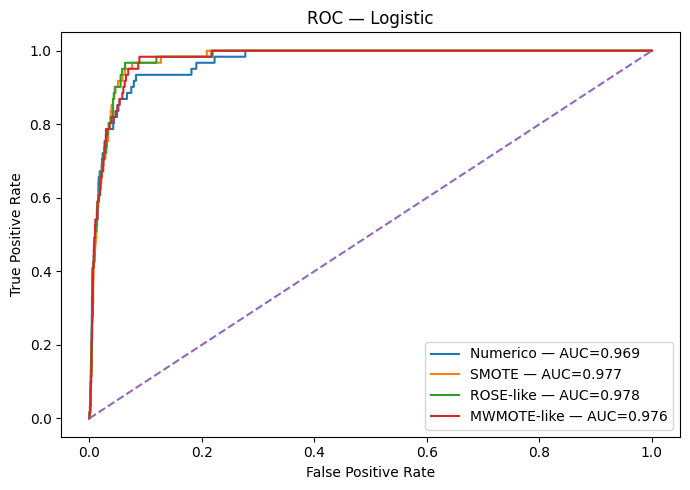

In [11]:

plt.figure(figsize=(7, 5))

for variant in ["Numerico", "SMOTE", "ROSE-like", "MWMOTE-like"]:
    score = roc_scores[("Logistic", variant)]
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, label=f"{variant} — AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Logistic")
plt.legend()
plt.tight_layout()
plt.show()


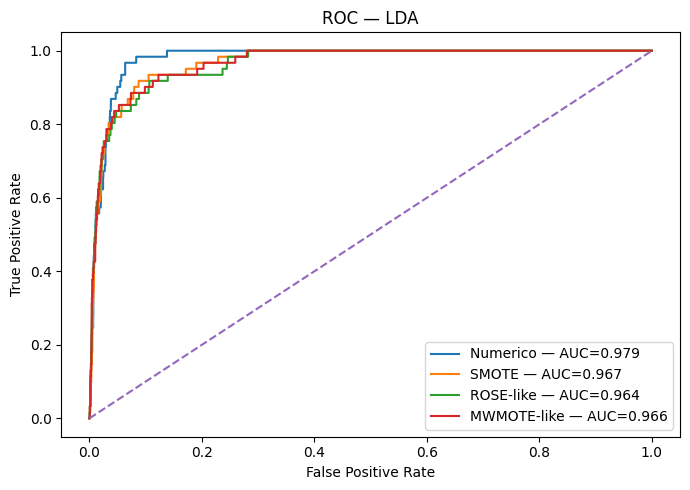

In [12]:

plt.figure(figsize=(7, 5))

for variant in ["Numerico", "SMOTE", "ROSE-like", "MWMOTE-like"]:
    score = roc_scores[("LDA", variant)]
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, label=f"{variant} — AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — LDA")
plt.legend()
plt.tight_layout()
plt.show()


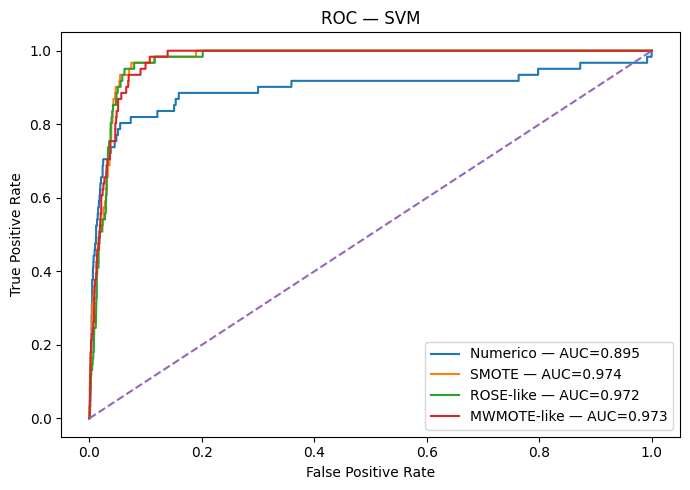

In [13]:

plt.figure(figsize=(7, 5))

for variant in ["Numerico", "SMOTE", "ROSE-like", "MWMOTE-like"]:
    score = roc_scores[("SVM", variant)]
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, label=f"{variant} — AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — SVM")
plt.legend()
plt.tight_layout()
plt.show()



## 12. Dataset completo: perché la replica è meno lineare

Gli script conservati contengono riferimenti come `test_all[,10]` e `test_all[,-10]`. Nel dataframe prodotto dallo script di cleaning che abbiamo ricevuto, la decima colonna è `hits`, non `transactionRevenue`.

Questo significa che lo **stato esatto del dataframe usato per produrre le tabelle finali non è interamente ricostruibile dai sei script salvati**.

Per non forzare il risultato, qui eseguiamo una versione Python coerente del dataset completo:

- categorie → one-hot encoding;
- variabili temporali → rappresentazione numerica;
- scaling globale solo per stabilità numerica e per avvicinarsi al comportamento di `e1071::svm`, che scala per default.

Il confronto con la tabella `Originale` della tesi va quindi letto come confronto **concettuale**, non come replica numerica.


In [14]:

X_all = model_df[categorical_features + numeric_all_features].copy()

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_cat = encoder.fit_transform(X_all[categorical_features])
X_num_all = X_all[numeric_all_features].to_numpy(float)

X_all_matrix = np.column_stack([X_cat, X_num_all])

scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all_matrix)

X_all_train = X_all_scaled[train_idx]
X_all_test = X_all_scaled[test_idx]

all_rows = []

for model_name, factory in model_factories.items():
    model = factory()
    m, score = score_model(
        model,
        X_all_train,
        y_train,
        X_all_test,
        y_test
    )
    all_rows.append(
        {"Model": model_name, "Variant": "Originale Python", **m}
    )

all_python_results = pd.DataFrame(all_rows)

display(
    all_python_results[
        [
            "Model", "Sensitivity", "Specificity",
            "Precision", "F1", "Accuracy", "ROC_AUC"
        ]
    ]
)


,Model,Sensitivity,Specificity,Precision,F1,Accuracy,ROC_AUC
0,Logistic,0.2787,0.9978,0.6071,0.3820,0.9890,0.9713
1,LDA,0.0000,0.9990,0.0000,0.0000,0.9868,0.9659
2,SVM,0.1148,0.9990,0.5833,0.1918,0.9882,0.8644



## 13. Cosa emerge dalla replica storica

La revisione dei dati, degli script e della tesi porta a una conclusione più interessante di una semplice conversione R → Python.

### Ciò che regge

- il dataset è realmente fortemente sbilanciato;
- l'accuracy è effettivamente fuorviante;
- il balancing aumenta fortemente la sensitivity;
- il miglioramento della sensitivity avviene al costo di molti falsi positivi;
- il ramo numerico è riproducibile abbastanza bene nella **struttura dei risultati**.

### Ciò che non è perfettamente riproducibile

- gli script salvati non contengono esplicitamente la dicotomizzazione della target, anche se la tesi conferma che era stata effettuata;
- alcune colonne vengono richiamate per posizione e non coincidono con il dataframe prodotto dallo script di cleaning;
- `test_smote` non esiste;
- alcune chiamate a `PRROC::roc.curve()` non usano l'interfaccia corretta;
- il codice MWMOTE elimina gli esempi positivi reali dal training finale;
- ROSE e MWMOTE dipendono da implementazioni R non disponibili 1:1 nell'ecosistema utilizzato qui;
- la tabella del bilanciamento nella tesi presenta le intestazioni acquisto/non acquisto invertite.

Questi punti non annullano le conclusioni della tesi, ma rendono molto utile una **seconda analisi metodologica indipendente**, che è l'obiettivo della Parte 3.



# Next — Parte 3: come rifarei l'esperimento nel 2026

La Parte 3 cambierà volutamente protocollo:

1. split **prima** del preprocessing;
2. holdout temporale per simulare dati futuri;
3. scaling fit soltanto sul training set;
4. balancing dentro la cross-validation;
5. hyperparameter tuning;
6. PR-AUC oltre alla ROC-AUC;
7. threshold tuning senza usare il test;
8. confronto cruciale:
   - **session-complete features** (`hits`, `pageviews`);
   - **early-session features**, cioè ciò che è disponibile prima che la sessione sia conclusa.
